Available masks:
  - lung_opacity_soft: shape (512, 512, 204)
  - consolidation_soft: shape (512, 512, 204)


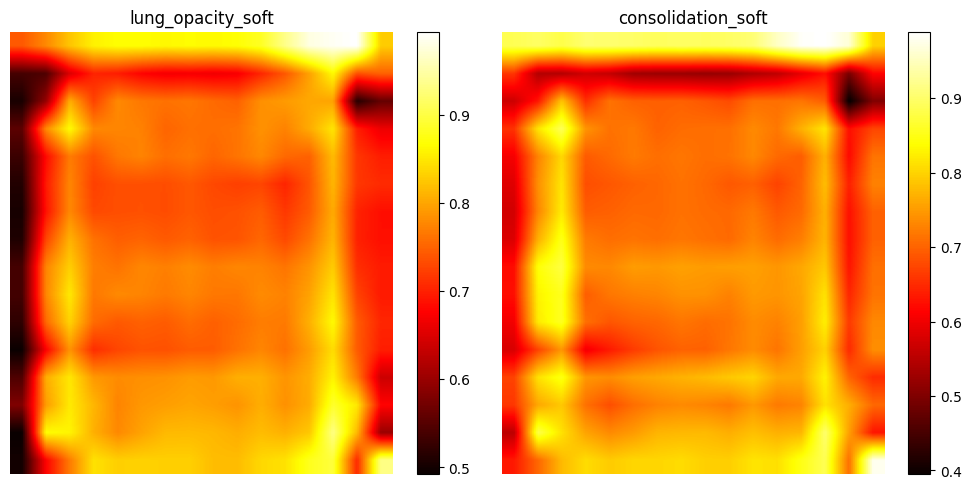


Done!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

# Load the npz file
npz_path = "/home/chest_ct/code/models/merlin/results_full/train_12991_a_1/localization_masks.npz"
data = np.load(npz_path)

print("Available masks:")
for key in data.files:
    print(f"  - {key}: shape {data[key].shape}")

# Display each localization mask
n_masks = len(data.files)
fig, axes = plt.subplots(1, n_masks, figsize=(5*n_masks, 5))

if n_masks == 1:
    axes = [axes]

for idx, (key, ax) in enumerate(zip(data.files, axes)):
    mask = data[key]
    
    # Use the middle slice if 3D
    if mask.ndim == 3:
        mid_slice = mask.shape[0] // 2
        display_data = mask[mid_slice]
    else:
        display_data = mask
    
    im = ax.imshow(display_data, cmap='hot', aspect='auto')
    ax.set_title(key, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\nDone!")

Keys in NPZ:
['fibrotic_changes_in__soft', 'fissural_air_cyst_in_soft']
fibrotic_changes_in__soft: shape=(512, 512, 293), dtype=float32
fissural_air_cyst_in_soft: shape=(512, 512, 293), dtype=float32

Using key: fibrotic_changes_in__soft
Mask array shape: (512, 512, 293)
Found 512 masks


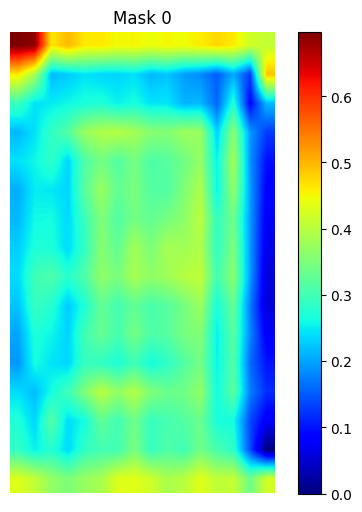

In [4]:
# Jupyter notebook cell
# Visualize masks stored in:
# /home/chest_ct/code/models/merlin/results_full/train_12991_a_1/localization_masks.npz

import numpy as np
import matplotlib.pyplot as plt

# Load NPZ file
npz_path = "/home/chest_ct/code/models/merlin/results_full/train_13102_a_1/localization_masks.npz"
data = np.load(npz_path)

# Show available keys
print("Keys in NPZ:")
print(data.files)

# Inspect shapes
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# ------------------------------------------------------------
# Pick first key automatically
# ------------------------------------------------------------
key = data.files[0]
masks = data[key]

print("\nUsing key:", key)
print("Mask array shape:", masks.shape)

# ------------------------------------------------------------
# Handle different possible shapes
# ------------------------------------------------------------

def show_mask(mask, title="mask"):
    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="jet")
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()

# Case 1: single 2D mask
if masks.ndim == 2:
    show_mask(masks, "Single Mask")

# Case 2: stack of masks (N, H, W)
elif masks.ndim == 3:
    print(f"Found {masks.shape[0]} masks")

    idx = 0  # change index to visualize different masks
    show_mask(masks[idx], f"Mask {idx}")

# Case 3: channels or volumes
elif masks.ndim == 4:
    print("4D tensor detected")

    # Example: (N, C, H, W)
    sample_idx = 0
    channel_idx = 0

    mask = masks[sample_idx, channel_idx]

    show_mask(mask, f"Sample {sample_idx} Channel {channel_idx}")

else:
    print("Unsupported shape:", masks.shape)

Mask keys: ['lung_opacity_soft', 'consolidation_soft']
Mask shape: (512, 512, 204)
CT shape: (5, 512, 512, 204)
CT volume shape after processing: (204, 512, 512)
Masks shape after transpose: (204, 512, 512)
Using slice 102
CT slice shape: (512, 512), Mask slice shape: (512, 512)


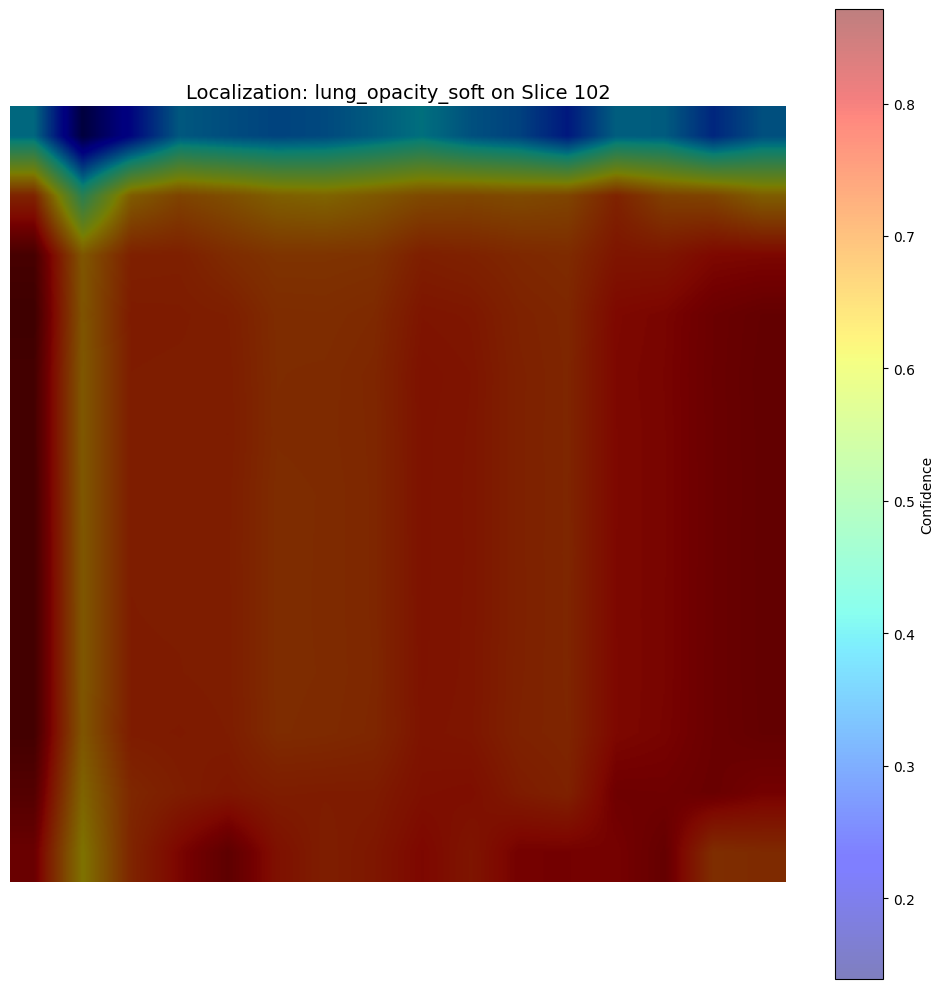

Visualized lung_opacity_soft on CT slice 102


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

# --------------------------------------------------
# Paths
# --------------------------------------------------
mask_path = "/home/chest_ct/code/models/merlin/results_full/train_12991_a_1/localization_masks.npz"
ct_path = "/home/chest_ct/code/data/segmentations/segmentations/train_12991_a_1.nii.gz"

# --------------------------------------------------
# Load localization masks
# --------------------------------------------------
mask_data = np.load(mask_path)

print("Mask keys:", mask_data.files)

mask_key = mask_data.files[0]
masks = mask_data[mask_key]

print("Mask shape:", masks.shape)

# --------------------------------------------------
# Load CT volume from NIfTI file
# --------------------------------------------------
ct_nifti = nib.load(ct_path)
ct_volume = ct_nifti.get_fdata()
print("CT shape:", ct_volume.shape)

# Handle different CT formats
# If (C, H, W, D): take first channel and transpose to (D, H, W)
if ct_volume.ndim == 4:
    ct_volume = ct_volume[0]  # Take first channel: (H, W, D)
    ct_volume = np.transpose(ct_volume, (2, 0, 1))  # Convert to (D, H, W)

# If (H, W, D): transpose to (D, H, W)
elif ct_volume.ndim == 3:
    ct_volume = np.transpose(ct_volume, (2, 0, 1))

print("CT volume shape after processing:", ct_volume.shape)

# Masks are typically (H, W, D), transpose to (D, H, W) to match CT
if masks.ndim == 3:
    masks = np.transpose(masks, (2, 0, 1))
    print("Masks shape after transpose:", masks.shape)

# --------------------------------------------------
# Select middle slice
# --------------------------------------------------
slice_idx = ct_volume.shape[0] // 2
ct_slice = ct_volume[slice_idx]
mask_slice = masks[slice_idx]

print(f"Using slice {slice_idx}")
print(f"CT slice shape: {ct_slice.shape}, Mask slice shape: {mask_slice.shape}")

# --------------------------------------------------
# Normalize CT for display (window/level)
# --------------------------------------------------
ct_display = ct_slice.astype(np.float32)
p1, p99 = np.percentile(ct_display, [1, 99])
ct_display = np.clip(ct_display, p1, p99)
ct_display = (ct_display - ct_display.min()) / (ct_display.max() - ct_display.min() + 1e-6)

# --------------------------------------------------
# Plot overlay
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# CT grayscale background
ax.imshow(ct_display, cmap="gray")

# Mask overlay with colormap
im = ax.imshow(mask_slice, cmap="jet", alpha=0.5)

ax.set_title(f"Localization: {mask_key} on Slice {slice_idx}", fontsize=14)
ax.axis("off")

plt.colorbar(im, ax=ax, label="Confidence")
plt.tight_layout()
plt.show()

print(f"Visualized {mask_key} on CT slice {slice_idx}")

Findings:
  0: Lung opacity - Ground-glass opacities in the peripheral subpleura
  1: Consolidation - Focal consolidations in the peripheral subpleural 
  2: Lung opacity - Nodular ground-glass opacities in the middle lobe 
  3: Lung opacity - Ground-glass opacities in the basal segments of bo
  4: Consolidation - Nodular consolidations in the basal segments of bo

CT shape: (204, 512, 512)
Available masks: ['lung_opacity_soft', 'consolidation_soft']


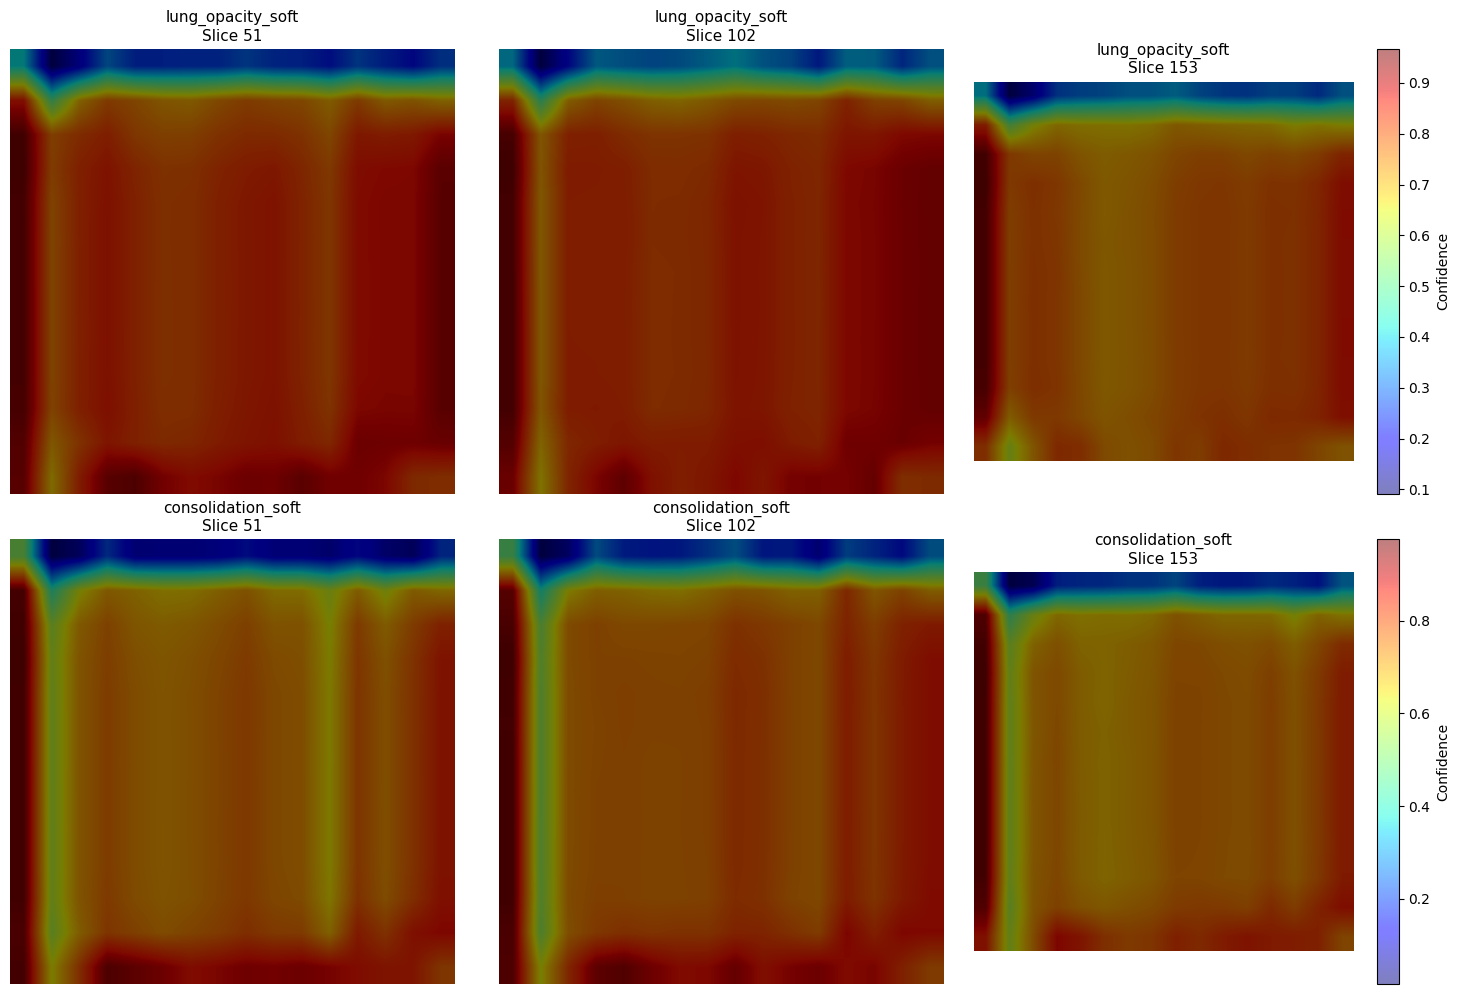


Multi-slice localization visualization complete!


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import json

# --------------------------------------------------
# Paths
# --------------------------------------------------
mask_path = "/home/chest_ct/code/models/merlin/results_full/train_12991_a_1/localization_masks.npz"
ct_path = "/home/chest_ct/code/data/segmentations/segmentations/train_12991_a_1.nii.gz"
findings_path = "/home/chest_ct/code/models/merlin/results_full/train_12991_a_1/findings.json"

# --------------------------------------------------
# Load data
# --------------------------------------------------
mask_data = np.load(mask_path)
ct_nifti = nib.load(ct_path)
ct_volume = ct_nifti.get_fdata()

with open(findings_path) as f:
    findings_info = json.load(f)

print("Findings:")
for idx, finding in findings_info['classified_findings'].items():
    print(f"  {idx}: {finding['category']} - {finding['text'][:50]}")

# --------------------------------------------------
# Preprocess CT volume
# --------------------------------------------------
if ct_volume.ndim == 4:
    ct_volume = ct_volume[0]  # Take first channel
    ct_volume = np.transpose(ct_volume, (2, 0, 1))
elif ct_volume.ndim == 3:
    ct_volume = np.transpose(ct_volume, (2, 0, 1))

# --------------------------------------------------
# Preprocess masks
# --------------------------------------------------
all_masks = {}
for key in mask_data.files:
    mask = mask_data[key]
    if mask.ndim == 3:
        mask = np.transpose(mask, (2, 0, 1))
    all_masks[key] = mask

print(f"\nCT shape: {ct_volume.shape}")
print(f"Available masks: {list(all_masks.keys())}")

# --------------------------------------------------
# Create multi-slice visualization
# --------------------------------------------------
n_slices = 3
slice_indices = [
    ct_volume.shape[0] // 4,        # 1/4 depth
    ct_volume.shape[0] // 2,        # middle
    3 * ct_volume.shape[0] // 4     # 3/4 depth
]

n_masks = len(all_masks)
fig, axes = plt.subplots(n_masks, n_slices, figsize=(15, 5*n_masks))

if n_masks == 1:
    axes = axes.reshape(1, -1)

for mask_idx, (mask_name, mask_data_vol) in enumerate(all_masks.items()):
    for slice_col, slice_idx in enumerate(slice_indices):
        ax = axes[mask_idx, slice_col]
        
        ct_slice = ct_volume[slice_idx]
        mask_slice = mask_data_vol[slice_idx]
        
        # Normalize CT
        ct_display = ct_slice.astype(np.float32)
        p1, p99 = np.percentile(ct_display, [1, 99])
        ct_display = np.clip(ct_display, p1, p99)
        ct_display = (ct_display - ct_display.min()) / (ct_display.max() - ct_display.min() + 1e-6)
        
        # Display CT
        ax.imshow(ct_display, cmap="gray")
        
        # Overlay mask
        im = ax.imshow(mask_slice, cmap="jet", alpha=0.5)
        
        ax.set_title(f"{mask_name}\nSlice {slice_idx}", fontsize=11)
        ax.axis("off")
        
        # Add colorbar to last slice of each row
        if slice_col == n_slices - 1:
            plt.colorbar(im, ax=ax, label="Confidence")

plt.tight_layout()
plt.show()

print("\nMulti-slice localization visualization complete!")

In [10]:

# --------------------------------------------------
# Summary of Predictions and Ground Truth Findings
# --------------------------------------------------
import pandas as pd

print("=" * 70)
print("GROUND TRUTH FINDINGS (from dataset)")
print("=" * 70)

gt_findings = findings_info['classified_findings']
pixels_gt = findings_info.get('pixels', {})

summary_data = []
for finding_id, finding_info in gt_findings.items():
    category = finding_info['category']
    text = finding_info['text'][:60] + "..." if len(finding_info['text']) > 60 else finding_info['text']
    pixels = pixels_gt.get(finding_id, 'N/A')
    
    summary_data.append({
        'Finding ID': finding_id,
        'Category': category,
        'Pixels': pixels,
        'Text': text
    })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

print("\n" + "=" * 70)
print("PREDICTIONS AVAILABLE")
print("=" * 70)
for mask_name, mask_vol in all_masks.items():
    print(f"  {mask_name}: shape {mask_vol.shape}, value range [{mask_vol.min():.3f}, {mask_vol.max():.3f}]")

print("\n" + "=" * 70)
print("PREDICTION STATISTICS")
print("=" * 70)
for mask_name, mask_vol in all_masks.items():
    mean_conf = mask_vol.mean()
    max_conf = mask_vol.max()
    print(f"{mask_name}:")
    print(f"  Mean confidence: {mean_conf:.3f}")
    print(f"  Max confidence:  {max_conf:.3f}")
    print(f"  >0.5 confidence voxels: {(mask_vol > 0.5).sum()}")
    print()

GROUND TRUTH FINDINGS (from dataset)
Finding ID      Category  Pixels                                                            Text
         0  Lung opacity   12432 Ground-glass opacities in the peripheral subpleural areas of...
         1 Consolidation     482 Focal consolidations in the peripheral subpleural areas of t...
         2  Lung opacity    1547 Nodular ground-glass opacities in the middle lobe of the rig...
         3  Lung opacity   47613 Ground-glass opacities in the basal segments of both lower l...
         4 Consolidation    1746 Nodular consolidations in the basal segments of both lower l...

PREDICTIONS AVAILABLE
  lung_opacity_soft: shape (204, 512, 512), value range [0.000, 1.000]
  consolidation_soft: shape (204, 512, 512), value range [0.000, 1.000]

PREDICTION STATISTICS
lung_opacity_soft:
  Mean confidence: 0.708
  Max confidence:  1.000
  >0.5 confidence voxels: 48449850

consolidation_soft:
  Mean confidence: 0.686
  Max confidence:  1.000
  >0.5 confidence

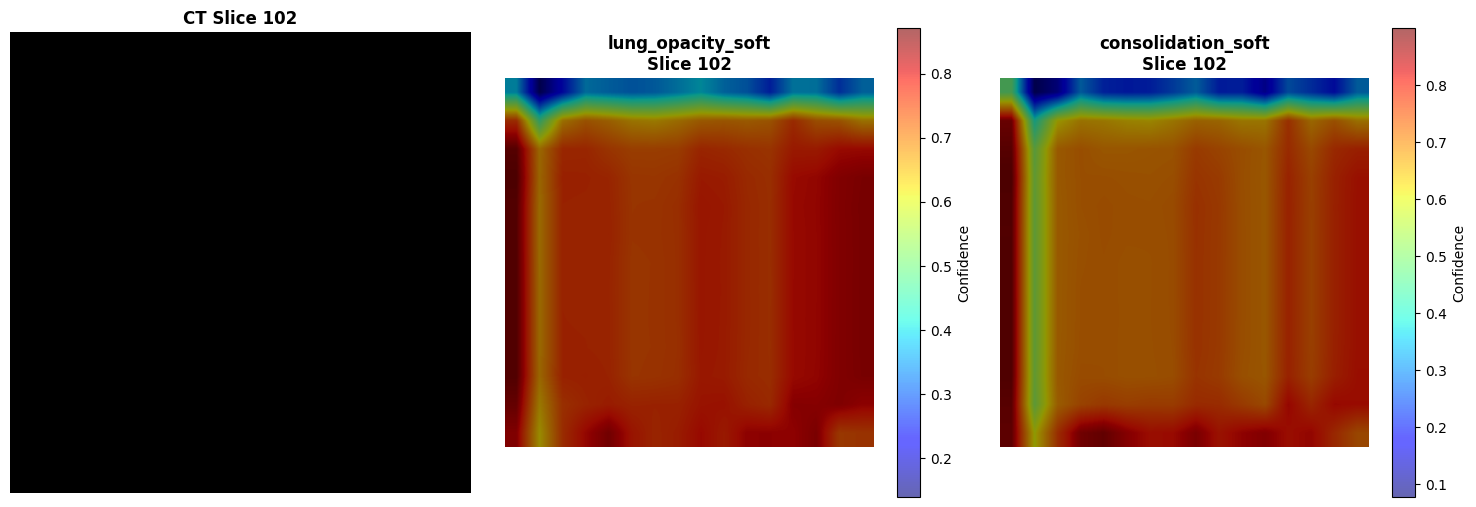


Comparison view of all predictions on slice 102


In [11]:

# --------------------------------------------------
# Side-by-side comparison: All masks on same slice
# --------------------------------------------------
slice_to_show = 102  # middle slice, or change as needed

fig, axes = plt.subplots(1, len(all_masks) + 1, figsize=(5*(len(all_masks)+1), 5))

# First subplot: CT only
ct_slice = ct_volume[slice_to_show]
ct_display = ct_slice.astype(np.float32)
p1, p99 = np.percentile(ct_display, [1, 99])
ct_display = np.clip(ct_display, p1, p99)
ct_display = (ct_display - ct_display.min()) / (ct_display.max() - ct_display.min() + 1e-6)

axes[0].imshow(ct_display, cmap="gray")
axes[0].set_title(f"CT Slice {slice_to_show}", fontsize=12, fontweight='bold')
axes[0].axis("off")

# Remaining subplots: masks overlaid on CT
for idx, (mask_name, mask_vol) in enumerate(all_masks.items()):
    ax = axes[idx + 1]
    
    # Display CT
    ax.imshow(ct_display, cmap="gray")
    
    # Overlay mask
    mask_slice = mask_vol[slice_to_show]
    im = ax.imshow(mask_slice, cmap="jet", alpha=0.6)
    
    ax.set_title(f"{mask_name}\nSlice {slice_to_show}", fontsize=12, fontweight='bold')
    ax.axis("off")
    
    plt.colorbar(im, ax=ax, label="Confidence")

plt.tight_layout()
plt.show()

print(f"\nComparison view of all predictions on slice {slice_to_show}")